In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from tqdm import tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Using device : ",device)

Using device :  cuda


In [2]:
# Paths
NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[1]
SEG_DATASET_DIR = BASE_DIR / "data" / "raw" / "kvasir-seg" / "Kvasir-SEG"
INPUT_DIR = SEG_DATASET_DIR / "images"
TARGET_DIR = SEG_DATASET_DIR / "masks"
MODEL_OUTPUT_DIR = BASE_DIR / "models" / "6-deeplab-v3-plus"
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
HEIGHT , WIDTH = 256 , 256
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

In [3]:
class SegmentationDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.BILINEAR)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy
        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32) / 255.0
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [4]:
# Create datasets
train_dataset = SegmentationDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 8
# Split into train/val (65/35)
train_size = int(0.65 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 650, Val samples: 350


In [ ]:
import segmentation_models_pytorch as smp

class DeepLabV3PlusModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = smp.DeepLabV3Plus(
            encoder_name="resnet18",        # Choose encoder, e.g. mobilenet_v2, efficientnet-b7, etc.
            encoder_weights="imagenet",     # Use pretrained weights for encoder initialization
            in_channels=3,                  # Input channels (RGB)
            classes=1,                      # Output channels (binary segmentation)
            activation='sigmoid'                # Sigmoid for binary segmentation
        )
        
    def forward(self, x):
        return self.model(x)

In [6]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice


class CombinedLoss(nn.Module):
    """Combines Dice Loss and BCE"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        
    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)
    
def calculate_iou(pred, target, threshold=0.5):
    """Calculate IoU metric"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


In [19]:
# Model, loss, optimizer
model = DeepLabV3PlusModel().to(device)
criterion = CombinedLoss(dice_weight=0.5, bce_weight=0.5)
dice_criterion = DiceLoss()
bce_criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
# Inspect model architecture
helper.inspect_model(
    model, 
    input_size=(1,3,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="DeepLabV3Plus"
)


MODEL ARCHITECTURE: DeepLabV3Plus
Layer (type:depth-idx)                                       Output Shape              Param #
DeepLabV3PlusModel                                           [1, 1, 256, 256]          --
├─DeepLabV3Plus: 1-1                                         [1, 1, 256, 256]          --
│    └─ResNetEncoder: 2-1                                    [1, 3, 256, 256]          --
│    │    └─Conv2d: 3-1                                      [1, 64, 128, 128]         9,408
│    │    └─BatchNorm2d: 3-2                                 [1, 64, 128, 128]         128
│    │    └─ReLU: 3-3                                        [1, 64, 128, 128]         --
│    │    └─MaxPool2d: 3-4                                   [1, 64, 64, 64]           --
│    │    └─Sequential: 3-5                                  [1, 64, 64, 64]           147,968
│    │    └─Sequential: 3-6                                  [1, 128, 32, 32]          525,568
│    │    └─Sequential: 3-7                   

In [8]:
dice_weight , bce_weight = 0.5 , 0.5

def train_epoch(model, loader, dice_criterion, bce_criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        
        # Calculate both losses
        dice_loss = dice_criterion(outputs, masks)
        bce_loss = bce_criterion(outputs, masks)
        loss = dice_weight*dice_loss + bce_weight*bce_loss  # Combined loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_dice_loss += dice_loss.item()
        total_bce_loss += bce_loss.item()
        total_iou += calculate_iou(outputs, masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n

def validate(model, loader, dice_criterion, bce_criterion, device):
    model.eval()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            
            outputs = model(imgs)
            
            # Calculate both losses
            dice_loss = dice_criterion(outputs, masks)
            bce_loss = bce_criterion(outputs, masks)
            loss = dice_weight*dice_loss + bce_weight*bce_loss
            
            total_loss += loss.item()
            total_dice_loss += dice_loss.item()
            total_bce_loss += bce_loss.item()
            total_iou += calculate_iou(outputs, masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n


In [9]:
history = {
    'train_loss': [], 'train_dice': [], 'train_bce': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_bce': [], 'val_iou': []
}
best_val_loss = float('inf')

In [ ]:
import gc
# Training with detailed loss tracking
epochs = 25


gc.collect()
torch.cuda.empty_cache()

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss, train_dice, train_bce, train_iou = train_epoch(
        model, train_loader, dice_criterion, bce_criterion, optimizer, device
    )
    val_loss, val_dice, val_bce, val_iou = validate(
        model, val_loader, dice_criterion, bce_criterion, device
    )
    # Store history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_bce'].append(train_bce)
    history['train_iou'].append(train_iou)
    
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_bce'].append(val_bce)
    history['val_iou'].append(val_iou)
    
    scheduler.step(val_loss)
    
    # Print detailed metrics
    print(f"TRAIN → Total: {train_loss:.4f} | Dice: {train_dice:.4f} | BCE: {train_bce:.4f} | IoU: {train_iou:.4f}")
    print(f"VAL   → Total: {val_loss:.4f} | Dice: {val_dice:.4f} | BCE: {val_bce:.4f} | IoU: {val_iou:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR / f"best_deeplab-v3-plus_model.pth")
        print("✓ Best model saved!")

Epoch 1/25


TRAIN → Total: 0.4703 | Dice: 0.5343 | BCE: 0.4062 | IoU: 0.5043
VAL   → Total: 0.3651 | Dice: 0.4531 | BCE: 0.2771 | IoU: 0.6088
✓ Best model saved!
Epoch 2/25


TRAIN → Total: 0.2740 | Dice: 0.3529 | BCE: 0.1950 | IoU: 0.7003
VAL   → Total: 0.2699 | Dice: 0.3574 | BCE: 0.1825 | IoU: 0.6705
✓ Best model saved!
Epoch 3/25


TRAIN → Total: 0.1925 | Dice: 0.2549 | BCE: 0.1300 | IoU: 0.7817
VAL   → Total: 0.2274 | Dice: 0.2937 | BCE: 0.1611 | IoU: 0.6997
✓ Best model saved!
Epoch 4/25


TRAIN → Total: 0.1469 | Dice: 0.1941 | BCE: 0.0998 | IoU: 0.8204
VAL   → Total: 0.1980 | Dice: 0.2530 | BCE: 0.1431 | IoU: 0.7030
✓ Best model saved!
Epoch 5/25


...

TRAIN → Total: 0.0330 | Dice: 0.0420 | BCE: 0.0240 | IoU: 0.9429
VAL   → Total: 0.1713 | Dice: 0.1648 | BCE: 0.1779 | IoU: 0.7407
Epoch 22/25


TRAIN → Total: 0.0275 | Dice: 0.0351 | BCE: 0.0199 | IoU: 0.9523
VAL   → Total: 0.1650 | Dice: 0.1578 | BCE: 0.1721 | IoU: 0.7490
Epoch 23/25


TRAIN → Total: 0.0262 | Dice: 0.0342 | BCE: 0.0181 | IoU: 0.9550
VAL   → Total: 0.1648 | Dice: 0.1546 | BCE: 0.1749 | IoU: 0.7526
Epoch 24/25


TRAIN → Total: 0.0235 | Dice: 0.0308 | BCE: 0.0162 | IoU: 0.9599
VAL   → Total: 0.1685 | Dice: 0.1561 | BCE: 0.1810 | IoU: 0.7495
Epoch 25/25


TRAIN → Total: 0.0236 | Dice: 0.0299 | BCE: 0.0173 | IoU: 0.9605
VAL   → Total: 0.1697 | Dice: 0.1549 | BCE: 0.1844 | IoU: 0.7517


In [11]:
        
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")
print(f"Best Validation IoU:       {max(history['val_iou']):.4f} (Epoch {np.argmax(history['val_iou'])+1})")
print(f"Final Train Loss:          {history['train_loss'][-1]:.4f}")
print(f"  ├─ Dice Loss:            {history['train_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['train_bce'][-1]:.4f}")
print(f"Final Validation Loss:     {history['val_loss'][-1]:.4f}")
print(f"  |─ Dice Loss:            {history['val_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['val_bce'][-1]:.4f}")


TRAINING SUMMARY
Best Validation Loss:      0.1561 (Epoch 16)
Best Validation IoU:       0.7526 (Epoch 23)
Final Train Loss:          0.0236
  ├─ Dice Loss:            0.0299
  └─ BCE Loss:             0.0173
Final Validation Loss:     0.1697
  |─ Dice Loss:            0.1549
  └─ BCE Loss:             0.1844


In [12]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_deeplab-v3-plus_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_deeplab-v3-plus_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")

print("\n✓ All models saved!")


✓ All models saved!


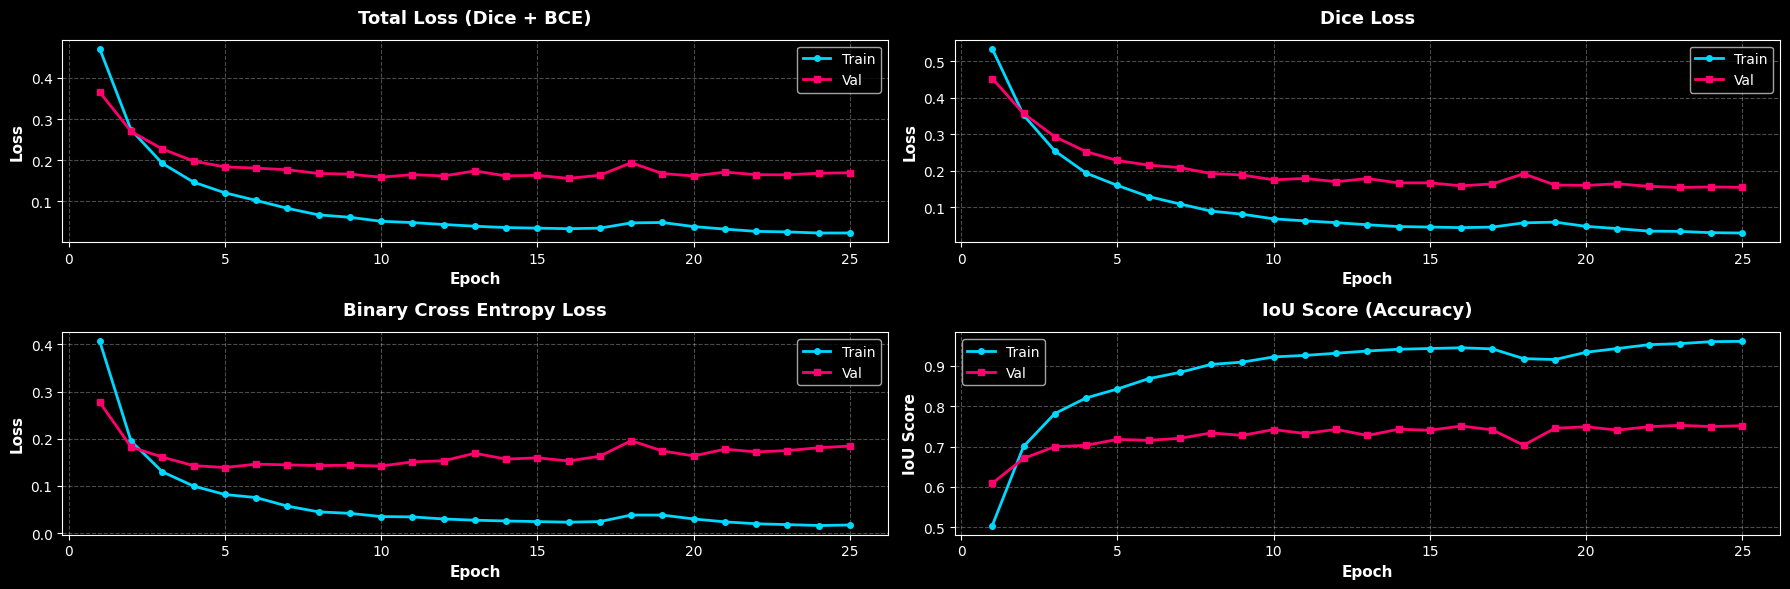

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 6))

epochs_range = range(1, len(history['train_loss']) + 1)

# Total Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 0].plot(epochs_range, history['val_loss'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Loss (Dice + BCE)', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# Dice Loss
axes[0, 1].plot(epochs_range, history['train_dice'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 1].plot(epochs_range, history['val_dice'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Dice Loss', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# BCE Loss
axes[1, 0].plot(epochs_range, history['train_bce'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 0].plot(epochs_range, history['val_bce'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Binary Cross Entropy Loss', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')

# IoU (Accuracy)
axes[1, 1].plot(epochs_range, history['train_iou'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 1].plot(epochs_range, history['val_iou'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('IoU Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('IoU Score (Accuracy)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'training_history_detailed.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

In [14]:
import cv2
import numpy as np

def create_overlay(rgb_img, mask, pred_mask=None, alpha=0.4):
    """Overlay where overlap is green and mismatched areas are red."""
    rgb_img = (rgb_img * 255).astype(np.uint8) if rgb_img.max() <= 1 else rgb_img.astype(np.uint8)
    if pred_mask is None:
        # Simple overlay with true mask
        overlay = rgb_img.copy()
        mask_colored = np.zeros_like(rgb_img)
        mask_colored[:, :, 1] = (mask * 255).astype(np.uint8)  # Green channel
        return cv2.addWeighted(rgb_img, 1-alpha, mask_colored, alpha, 0)
    # Binarize masks
    mask_bin = (mask > 0.5).astype(np.uint8)
    pred_bin = (pred_mask > 0.5).astype(np.uint8)
    
    overlay = rgb_img.copy()
    color_layer = np.zeros_like(rgb_img)

    # Overlap (TP): Green
    tp = (mask_bin & pred_bin)
    color_layer[tp == 1] = (0, 255, 0)
    
    # Non-overlapping (errors): Red
    error = (mask_bin ^ pred_bin)  # XOR = non-overlapping
    color_layer[error == 1] = (255, 0, 0)

    # Blend with original image
    overlay = cv2.addWeighted(rgb_img, 1 - alpha, color_layer, alpha, 0)

    return overlay




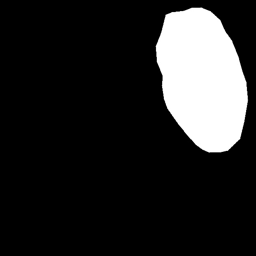
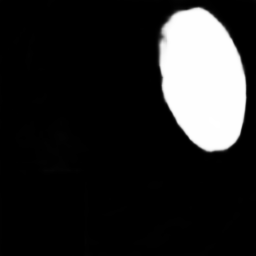
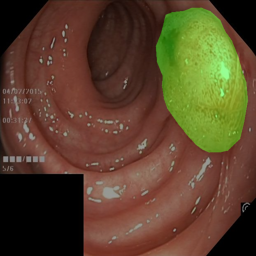
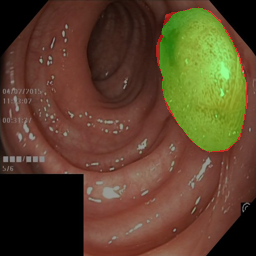

In [15]:
# # Load best model
model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_deeplab-v3-plus_model.pth"))
model.eval()
# Get random images
image_paths = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])
# Load and preprocess
img_pil = Image.open(image_paths[0]).convert('RGB')
mask_pil = Image.open(image_paths[1]).convert('L')
img_resized = img_pil.resize((HEIGHT,WIDTH))
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
# Predict
with torch.no_grad():
    pred = model(img_tensor).cpu().numpy()[0, 0]
# Convert for visualization
img_np = np.array(img_resized)
mask_np = np.array(mask_pil.resize((HEIGHT,WIDTH))) / 255.0
# Create overlays
overlay_true = create_overlay(img_np, mask_np)
overlay_pred = create_overlay(img_np, mask_np, pred)
# Display using helper
helper.show_grid({
    # 'RGB Image': img_np,
    'True Mask': (mask_np * 255).astype(np.uint8),
    'Predicted Mask': (pred * 255).astype(np.uint8),
    'RGB + True Mask': overlay_true,
    'RGB + Predicted': overlay_pred
}, grid="row",width=1300)

In [16]:
def evaluate_validation_set(model, val_image_dir, val_mask_dir, device, img_size=(HEIGHT,WIDTH), sample_pixels=10000):
    """
    Efficient evaluation with pixel sampling to avoid memory issues
    
    Args:
        sample_pixels: Number of pixels to sample per image for confusion matrix
    """
    model.eval()
    
    val_images = sorted(list(Path(val_image_dir).glob('*.png')) + list(Path(val_image_dir).glob('*.jpg')))
    val_masks = sorted(list(Path(val_mask_dir).glob('*.png')) + list(Path(val_mask_dir).glob('*.jpg')))
    
    # Use limited subset if too many images
    if len(val_images) > 100:
        print(f"Using 100 images for evaluation (out of {len(val_images)})")
        val_images = val_images[:100]
        val_masks = val_masks[:100]
    
    all_preds = []
    all_targets = []
    ious = []
    precisions = []
    recalls = []
    
    with torch.no_grad():
        for img_path, mask_path in tqdm(zip(val_images, val_masks), total=len(val_images), desc="Evaluating"):
            # Load and preprocess
            img = Image.open(img_path).convert('RGB').resize(img_size)
            mask = Image.open(mask_path).convert('L').resize(img_size)
            
            img_tensor = torch.from_numpy(np.array(img).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
            mask_np = np.array(mask) / 255.0
            
            # Predict
            pred = model(img_tensor).cpu().numpy()[0, 0]
            
            # Binary masks
            pred_bin = (pred > 0.5).astype(np.uint8)
            mask_bin = (mask_np > 0.5).astype(np.uint8)
            
            # Sample pixels randomly to avoid memory issues
            h, w = pred_bin.shape
            total_pixels = h * w
            
            if total_pixels > sample_pixels:
                # Random sampling
                indices = np.random.choice(total_pixels, sample_pixels, replace=False)
                pred_flat = pred_bin.flatten()[indices]
                mask_flat = mask_bin.flatten()[indices]
            else:
                pred_flat = pred_bin.flatten()
                mask_flat = mask_bin.flatten()
            
            all_preds.extend(pred_flat)
            all_targets.extend(mask_flat)
            
            # Calculate per-image metrics
            intersection = (pred_bin * mask_bin).sum()
            union = pred_bin.sum() + mask_bin.sum() - intersection
            iou = intersection / (union + 1e-6)
            ious.append(iou)
            
            # Per-image precision and recall
            tp = (pred_bin * mask_bin).sum()
            fp = (pred_bin * (1 - mask_bin)).sum()
            fn = ((1 - pred_bin) * mask_bin).sum()
            
            precision = tp / (tp + fp + 1e-6)
            recall = tp / (tp + fn + 1e-6)
            
            precisions.append(precision)
            recalls.append(recall)
    
    # Convert to numpy for faster computation
    all_preds = np.array(all_preds, dtype=np.uint8)
    all_targets = np.array(all_targets, dtype=np.uint8)
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision = np.mean(precisions)
    recall = np.mean(recalls)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    mean_iou = np.mean(ious)
    
    cm = confusion_matrix(all_targets, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'confusion_matrix': cm,
        'n_images': len(val_images)
    }


Using 100 images for evaluation (out of 1000)


Evaluating: 100%|██████████| 100/100 [00:08<00:00, 12.40it/s]



METRICS ON TRAINING DATASET==================================================
VALIDATION METRICS
Pixel Accuracy:  0.9765
Precision:       0.9025
Recall:          0.9079
F1 Score:        0.9052
Mean IoU:        0.8369


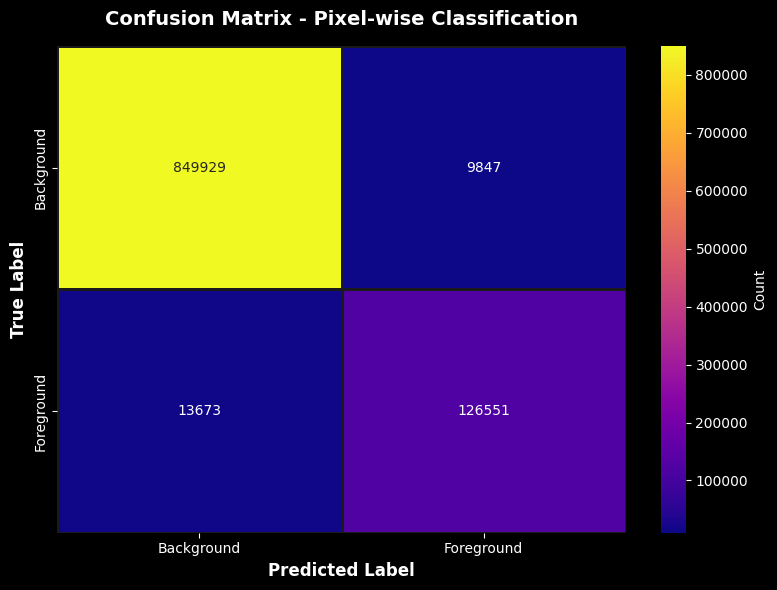

In [17]:
# Evaluate on validation set
metrics = evaluate_validation_set(model, INPUT_DIR, TARGET_DIR, device)

# Print metrics
print("\nMETRICS ON TRAINING DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

Using 100 images for evaluation (out of 196)


Evaluating: 100%|██████████| 100/100 [00:08<00:00, 12.32it/s]



METRICS ON VALIDATION DATASET==================================================
VALIDATION METRICS
Pixel Accuracy:  0.9895
Precision:       0.8780
Recall:          0.8869
F1 Score:        0.8825
Mean IoU:        0.8147


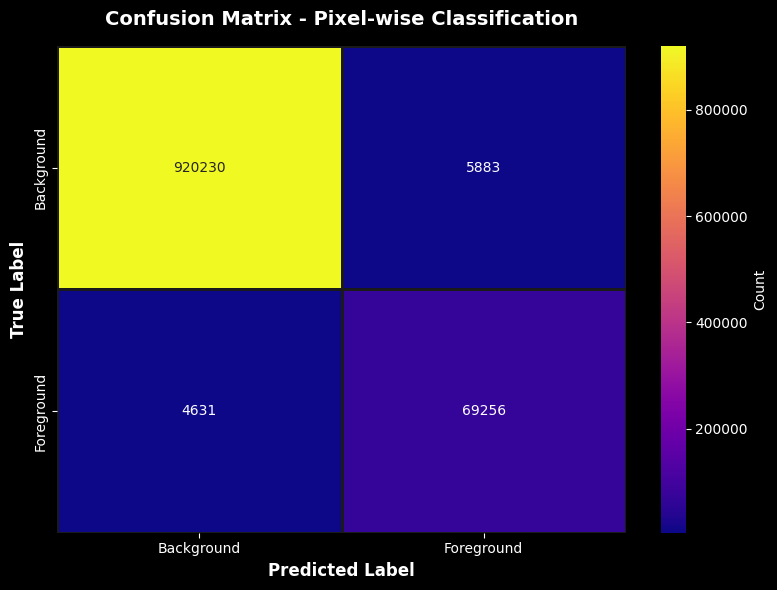

In [18]:
VAL_DIR = BASE_DIR / "data" / "raw" / "kvasir-sessile" / "sessile-main-Kvasir-SEG"
VAL_INPUT_DIR = VAL_DIR / "images"
VAL_MASK_DIR = VAL_DIR / "masks"
# Evaluate on validation set
metrics = evaluate_validation_set(model, VAL_INPUT_DIR, VAL_MASK_DIR, device)

# Print metrics
print("\nMETRICS ON VALIDATION DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()